# Schrödinger's horse: numerical integrators with `array-api-compat`

We evolve an image under the Schrödinger equation for a 2D quantum harmonic oscillator,

$$\partial_t \psi = iH\psi, \qquad H = K + V,$$

where the potential $V=\frac{1}{2}(x^2 + y^2)$ depends only on **position** and the kinetic energy $
K=\frac{1}{2}(\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2})$ depends
only on **momentum**. The potential $V$ is
diagonal in position space, $K$ is diagonal in momentum space and the FFT moves the state
between the two.

**The exact solution is a single exponential.** $H$ does not change with time, so the
entire evolution is one operator exponential:

$$\psi(t) = e^{iHt}\,\psi(0)$$

— differentiate it and the Schrödinger equation comes back, which verifies the
solution. Every method in this notebook is a way of computing that exponential. So
why is it hard? On our $128 \times 128$ grid the state has $N = 16{,}384$ unknowns,
so $H$ is a matrix with $N^2 \approx 2.7 \times 10^8$ entries, and a dense matrix
exponential costs $\mathcal{O}(N^3)$ operations. We never build $H$, let alone
exponentiate it directly: every method below only ever needs $H$ *applied to a
vector* — two FFTs and elementwise multiplies.

The oscillator rotates position into momentum. A quarter turn of phase space is the
Fourier transform; a half turn shows the image upside down; a full turn brings it
exactly back:

| time | exact state |
|---|---|
| $t = \pi/2$ | the Fourier transform of the image |
| $t = \pi$ | the image upside down |
| $t = 3\pi/2$ | the inverse Fourier transform |
| $t = 2\pi$ | the original image, exactly revived |

**Array agnostic maths:** the integrators in `quantum_oscillator.operators` never import
NumPy or PyTorch. They call `array_namespace(psi)` from `array-api-compat` and do the
maths in whatever namespace the array belongs to. We write the maths once — *the data
decides where it runs*. At the end we hand the very same functions a `torch` tensor on
the Apple-silicon GPU and benchmark it against NumPy.

## Contents

1. [Forward Euler always blows up](#1-forward-euler-always-blows-up)
2. [Operator splitting: unitary by construction, but a splitting error](#2-operator-splitting-unitary-by-construction-but-a-splitting-error)
3. [Convergence: each method at its theoretical order](#3-convergence-each-method-at-its-theoretical-order)
4. [One giant step with a high-order method](#4-one-giant-step-with-a-high-order-method)
5. [The grand tour: π/2, π, 3π/2, 2π](#5-the-grand-tour-pi2-pi-3pi2-2pi)
6. [Let the data decide: NumPy CPU vs torch on the Apple-silicon GPU](#6-let-the-data-decide-numpy-cpu-vs-torch-on-the-apple-silicon-gpu)
7. [Phase retrieval: recovering the horse from a noisy, phaseless camera](#7-phase-retrieval-recovering-the-horse-from-a-noisy-phaseless-camera)
8. [Recap](#recap)


In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np

from quantum_oscillator.data import get_initial_state
from quantum_oscillator.operators import (
    evolve,
    forward_euler_step,
    lie_trotter_step,
    suzuki_trotter_step,
)
from quantum_oscillator.physics import get_propagators
from quantum_oscillator.plotting import show_states, tidy
from quantum_oscillator.utils import state_distance, to_host

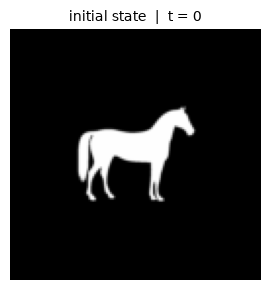

In [2]:
N = 128  # grid points per side (the gallery later uses 256)
L = math.sqrt(math.pi * N / 2)  # box size chosen so that t = pi/2 is exactly an FFT

psi0 = get_initial_state(N, L, state_image="horse", blur=0.0, backend="numpy")
V, K = get_propagators(N, L, backend="numpy")

show_states([psi0], ["initial state  |  t = 0"])

## 1. Forward Euler always blows up

Over one step the exact solution is the exponential, and the exponential *is* its
Taylor series

$$\psi(t + \Delta t) \;=\; e^{i\,\Delta t\,H}\,\psi(t)
\;=\; \sum_{k=0}^{\infty} \frac{(i\,\Delta t\,H)^k}{k!}\,\psi(t)
\;=\; \Big(1 + i\,\Delta t\,H - \tfrac{1}{2}\Delta t^2 H^2 - \cdots\Big)\,\psi(t).$$

The Forward Euler integrator truncates this equality after two terms

$$\psi_{n+1} = (1 + i\,\Delta t\, H)\,\psi_n.$$

For any eigenvalues $E$ of $H$, one step multiplies that part of the state by
$1 + i\,\Delta t\,E$, whose size is

$$|1 + i\,\Delta t\,E| = \sqrt{1 + (\Delta t\,E)^2},$$

which is **larger than one for every $E$ and every $\Delta t$**. There is no step size
that makes this method conserve the norm: it grows on every single step. Halving
$\Delta t$ delays the blow-up — it does not prevent it.

dt = 0.003: the norm passed 1,000,000 after 80 steps


dt = 0.001: the norm passed 1,000,000 after 496 steps


dt = 0.0003: the norm passed 1,000,000 after 5194 steps


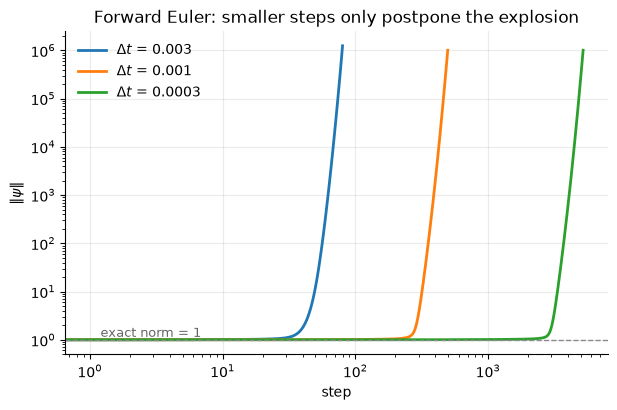

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.2))

# evolve(track_norm=True) records ||psi|| after every step; march each step
# size well past the blow-up and read off where the norm passes a million
for dt, n_steps in [(3e-3, 120), (1e-3, 700), (3e-4, 7000)]:
    _, norms = evolve(
        psi0,
        V,
        K,
        dt * n_steps,
        n_steps,
        step_fn=forward_euler_step,
        track_norm=True,
    )
    crossed = int(np.argmax(np.asarray(norms) > 1e6))
    print(f"dt = {dt:g}: the norm passed 1,000,000 after {crossed} steps")
    ax.loglog(norms[: crossed + 1], lw=2, label=f"$\\Delta t$ = {dt:g}")

ax.axhline(1.0, color="0.55", lw=1, ls="--")
ax.text(1.2, 1.15, "exact norm = 1", color="0.4", fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel(r"$\|\psi\|$")
ax.set_title("Forward Euler: smaller steps only postpone the explosion")
ax.legend(frameon=False)
tidy(ax)
plt.show()

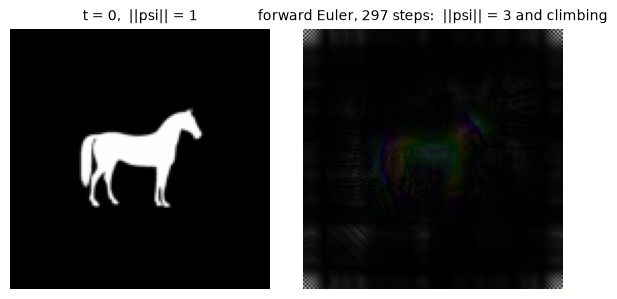

In [4]:
# What the explosion looks like. The finest-detail modes have the largest
# eigenvalues, so they grow fastest: the horse boils away from its sharp edges.
# Single precision is plenty for watching a blow-up -- and half the memory
# traffic makes the thousands of FFT steps quicker.
psi = get_initial_state(N, L, state_image="horse", blur=0.0, precision="single")
V_c64, K_c64 = get_propagators(N, L, precision="single")
steps = 0
while float(np.linalg.norm(to_host(psi))) < 3.0:
    psi = forward_euler_step(psi, V_c64, K_c64, 1e-3)
    steps += 1

show_states(
    [psi0, psi],
    ["t = 0,  ||psi|| = 1", f"forward Euler, {steps} steps:  ||psi|| = 3 and climbing"],
)

## 2. Operator splitting: unitary by construction, but a splitting error

Splitting takes the opposite deal. Instead of truncating the exponential, split it:

$$e^{-i(K+V)\Delta t} \;\approx\; e^{-iK\Delta t}\, e^{-iV\Delta t}
\qquad\text{(Lie–Trotter)}.$$

Each factor on the right is easy and **exact**: $e^{-iV\Delta t}$ is an elementwise
phase in position space, $e^{-iK\Delta t}$ is an elementwise phase in momentum space.
One step is two FFTs and two multiplies — and because every factor is a pure phase,
the norm is conserved **exactly, at any step size**. This method can never blow up.

The price: $K$ and $V$ do not commute — kick-then-drift is not the same as
drift-then-kick — so the split product is not quite the true exponential. Each step
carries a small *splitting error* that shrinks with $\Delta t$.

Watch what that error does when the step is huge: one single step across a whole
period, $\Delta t = 2\pi$. The norm stays exactly 1, but the amplitude lands in
completely the wrong place.

norm after one Lie-Trotter step of dt = 2*pi: 1.000000000000


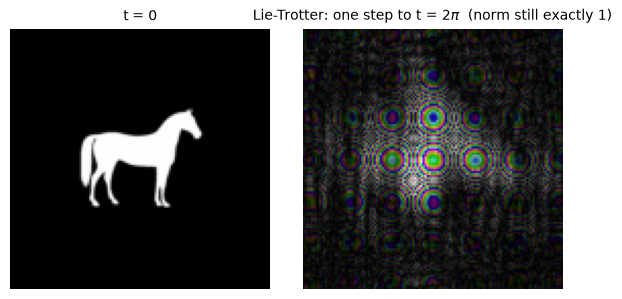

In [5]:
one_giant_step = lie_trotter_step(psi0, V, K, 2 * math.pi)

print(
    f"norm after one Lie-Trotter step of dt = 2*pi: "
    f"{np.linalg.norm(to_host(one_giant_step)):.12f}"
)

show_states(
    [psi0, one_giant_step],
    ["t = 0", "Lie-Trotter: one step to t = 2$\\pi$  (norm still exactly 1)"],
)

Perfectly unitary, perfectly wrong. Forward Euler fails loudly (the norm diverges);
splitting fails politely (the norm is exact, the *phases* are scrambled). The fix is
the usual one: refine the step.

## 3. Convergence: each method at its theoretical order

Take more, smaller steps and the splitting error must die — at **order 1** for
Lie–Trotter (halve the step, halve the error) and at **order 4** and **order 8** for
the Suzuki–Trotter compositions built in section 4 (halve the step, divide the error
by 16, or by 256).

Two small choices make the measurement clean:

- **Where to measure.** Stopping exactly at a revival flatters Lie–Trotter (its errors
  partly cancel over whole periods), so we stop a quarter period later, at
  $t = 8.5\pi$ — where the exact answer is the Fourier transform of the image — and
  compare against a reference run so accurate its own error is off the bottom of the
  plot.
- **A slightly smoothed image.** The silhouette's razor-sharp edges contain extremely
  fine detail that would need far smaller steps before the textbook rates appear, so
  for this study we blur the image by 2 pixels.

The dotted guides in the left panel have slopes of exactly $-1$, $-4$ and $-8$: each
measured curve runs parallel to its guide, confirming the theoretical order.

Steps are not the honest currency, though — a Lie–Trotter step is one FFT pair
(an `fft2` and an `ifft2`), but an order-4 step hides 5 Strang sub-steps and an
order-8 step hides 125, so equal step counts mean wildly unequal work. The right
panel replots the same errors against the **number of FFT pairs** each run
performed — the work that actually dominates the runtime. Read it horizontally: at
any target accuracy, the leftmost curve is the cheapest method — and the higher the
accuracy you demand, the more decisively high order wins.

Lie-Trotter (order 1)      observed order 0.98


Suzuki-Trotter (order 4)   observed order 4.00


Suzuki-Trotter (order 8)   observed order 8.32


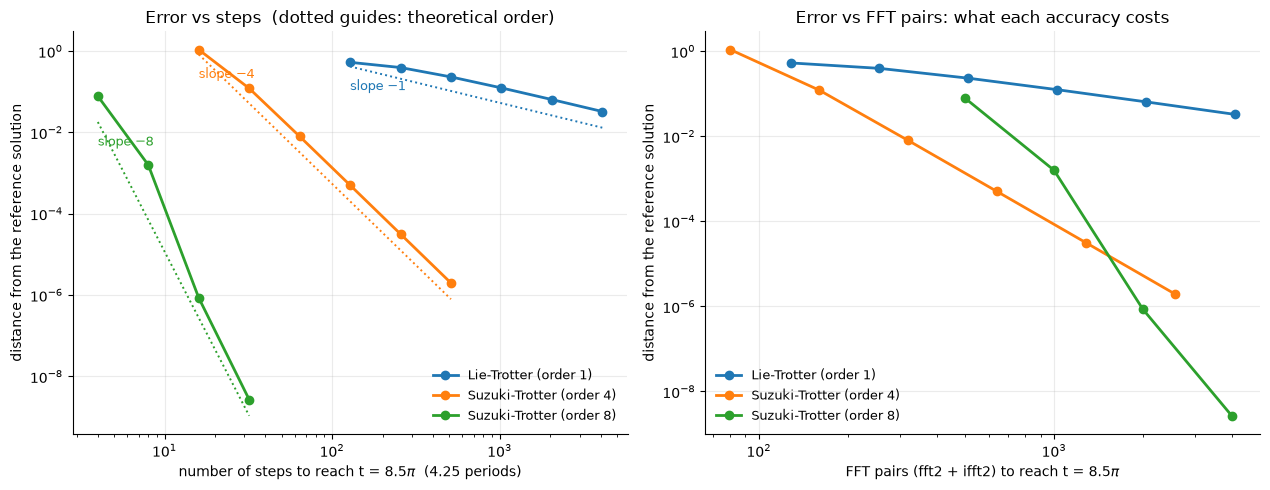

In [6]:
T = 8.5 * math.pi  # 4.25 periods: the exact answer is the Fourier transform
psi_smooth = get_initial_state(N, L, state_image="horse", blur=2.0, backend="numpy")


def suzuki4_step(psi, V, K, dt):
    return suzuki_trotter_step(psi, V, K, dt, order=4)


def suzuki8_step(psi, V, K, dt):
    return suzuki_trotter_step(psi, V, K, dt, order=8)


# the reference: order 8 with tiny steps, error ~1e-10 (off the bottom of the plot)
reference = evolve(psi_smooth, V, K, T, 128, step_fn=suzuki8_step)

experiments = [
    # label, step function, order,
    # FFT pairs (fft2 + ifft2) per step, step counts
    (
        "Lie-Trotter (order 1)",
        lie_trotter_step,
        1,
        1,
        [128, 256, 512, 1024, 2048, 4096],
    ),
    ("Suzuki-Trotter (order 4)", suzuki4_step, 4, 5, [16, 32, 64, 128, 256, 512]),
    ("Suzuki-Trotter (order 8)", suzuki8_step, 8, 125, [4, 8, 16, 32]),
]

fig, (ax_steps, ax_cost) = plt.subplots(1, 2, figsize=(12.8, 5.0))

for label, step_fn, order, pairs_per_step, step_counts in experiments:
    errors = [
        state_distance(evolve(psi_smooth, V, K, T, n, step_fn), reference)
        for n in step_counts
    ]

    (line,) = ax_steps.loglog(step_counts, errors, "o-", lw=2, label=label)

    # dotted guide with the theoretical slope, anchored just below the last point
    guide = [0.4 * errors[-1] * (step_counts[-1] / n) ** order for n in step_counts]
    ax_steps.loglog(step_counts, guide, ":", color=line.get_color(), lw=1.4)
    ax_steps.text(
        step_counts[0],
        guide[0] * 0.45,
        f"slope $-{order}$",
        color=line.get_color(),
        fontsize=9,
        va="top",
    )

    # the same errors against the honest currency: a "step" hides very
    # different work per method, so replot against the FFT pairs it took
    fft_pairs = [n * pairs_per_step for n in step_counts]
    ax_cost.loglog(fft_pairs, errors, "o-", lw=2, color=line.get_color(), label=label)

    # doubling the steps divides the error by 2^order; check the last doubling
    observed = math.log2(errors[-2] / errors[-1])
    print(f"{label:26s} observed order {observed:.2f}")

ax_steps.set_xlabel("number of steps to reach t = 8.5$\\pi$  (4.25 periods)")
ax_steps.set_ylabel("distance from the reference solution")
ax_steps.set_title("Error vs steps  (dotted guides: theoretical order)")
ax_steps.legend(frameon=False, fontsize=9)
tidy(ax_steps)

ax_cost.set_xlabel("FFT pairs (fft2 + ifft2) to reach t = 8.5$\\pi$")
ax_cost.set_ylabel("distance from the reference solution")
ax_cost.set_title("Error vs FFT pairs: what each accuracy costs")
ax_cost.legend(frameon=False, fontsize=9)
tidy(ax_cost)

fig.tight_layout()
plt.show()

## 4. One large step with a high-order method

Suzuki-trotter allows for $n^{th}$ order splitting methods. So, can a *single step* of size $\Delta t = \pi$ flip the horse upside down?

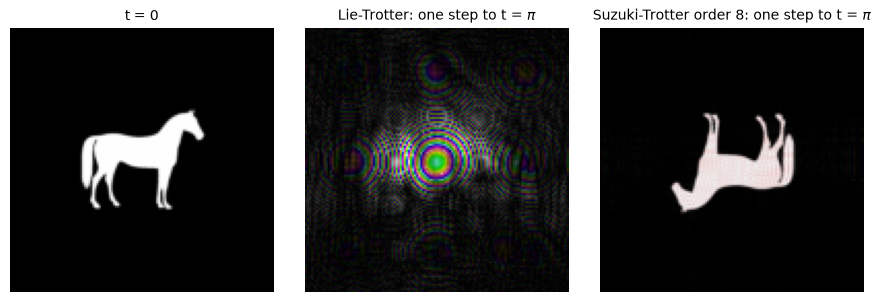

In [7]:
one_lie_step = lie_trotter_step(psi0, V, K, math.pi)
one_suzuki_step = suzuki_trotter_step(psi0, V, K, math.pi, order=8)

show_states(
    [psi0, one_lie_step, one_suzuki_step],
    [
        "t = 0",
        "Lie-Trotter: one step to t = $\\pi$",
        "Suzuki-Trotter order 8: one step to t = $\\pi$",
    ],
)

One "step", and the image lands upside down. (It is not free, of course — the
125 hidden sub-steps cost 250 FFT pairs. What matters is error per FFT and high order wins whenever you need accuracy.)

## 5. Full rotation through position and momentum space: $\pi/2$, $\pi$, $3\pi/2$, $2\pi$

The oscillator rotates position into momentum: every quarter period is a Fourier
transform of the whole image and four quarter turns bring it back.

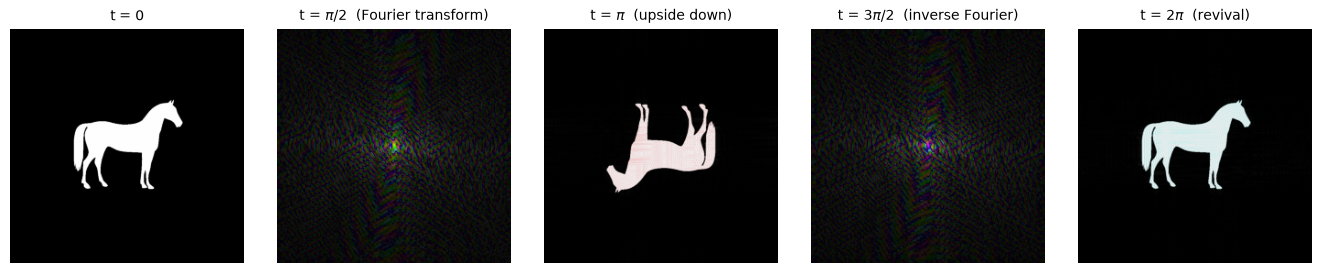

revival error: distance from the start = 0.036


In [8]:
N_tour = 256
L_tour = math.sqrt(math.pi * N_tour / 2)

psi_start = get_initial_state(
    N_tour, L_tour, state_image="horse", blur=0.0, backend="numpy"
)
V_tour, K_tour = get_propagators(N_tour, L_tour, backend="numpy")

frames = [psi_start]
psi = psi_start
for _ in range(4):  # four quarter periods
    psi = evolve(psi, V_tour, K_tour, math.pi / 2, 64)
    frames.append(psi)

show_states(
    frames,
    [
        "t = 0",
        "t = $\\pi$/2  (Fourier transform)",
        "t = $\\pi$  (upside down)",
        "t = 3$\\pi$/2  (inverse Fourier)",
        "t = 2$\\pi$  (revival)",
    ],
    size=2.7,
    gamma=[1, 0.35, 1, 0.35, 1],  # brighten the two Fourier frames
)

print(f"revival error: distance from the start = {state_distance(psi, psi_start):.3f}")

## 6. Array-api-compat: NumPy CPU vs `torch` on the Apple-silicon GPU


The payoff of writing against the Array API: **nothing in the maths changes.**
Inside `lie_trotter_step`, two characters changed — `np` became `xp` — and `xp` comes
from the array itself, via `xp = array_namespace(psi, V)`. 

   grid       NumPy       torch   speed-up
  256^2     1.95 ms     0.15 ms     13.3x
  512^2     9.57 ms     0.23 ms     42.0x
 1024^2    41.38 ms     0.60 ms     68.5x


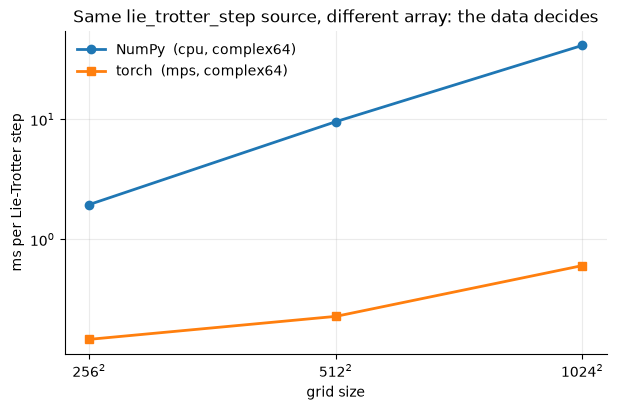

In [9]:
import torch

from quantum_oscillator.utils import DEVICE  # "mps" on Apple silicon, else "cpu"


def ms_per_step(backend, n, n_steps=50):
    """Time lie_trotter_step on an n x n grid, for the given backend."""
    box = math.sqrt(math.pi * n / 2)
    # single precision on both backends so the race measures hardware, not dtype
    psi = get_initial_state(
        n, box, state_image="horse", blur=0.0, backend=backend, precision="single"
    )
    V_b, K_b = get_propagators(n, box, backend=backend, precision="single")
    on_gpu = backend == "torch" and DEVICE == "mps"

    for _ in range(5):  # warm-up
        psi = lie_trotter_step(psi, V_b, K_b, 1e-3)
    if on_gpu:
        torch.mps.synchronize()

    start = time.perf_counter()
    for _ in range(n_steps):
        psi = lie_trotter_step(psi, V_b, K_b, 1e-3)
    if on_gpu:
        torch.mps.synchronize()  # the GPU runs asynchronously: wait before timing
    return (time.perf_counter() - start) / n_steps * 1e3


sizes = [256, 512, 1024]
numpy_ms = [ms_per_step("numpy", n) for n in sizes]
torch_ms = [ms_per_step("torch", n) for n in sizes]

print("   grid       NumPy       torch   speed-up")
for n, cpu, gpu in zip(sizes, numpy_ms, torch_ms):
    print(f" {n:4d}^2  {cpu:7.2f} ms  {gpu:7.2f} ms  {cpu / gpu:7.1f}x")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(sizes, numpy_ms, "o-", lw=2, label="NumPy  (cpu, complex64)")
ax.loglog(sizes, torch_ms, "s-", lw=2, label=f"torch  ({DEVICE}, complex64)")
ax.set_xticks(sizes, [f"{n}$^2$" for n in sizes])
ax.minorticks_off()
ax.set_xlabel("grid size")
ax.set_ylabel("ms per Lie-Trotter step")
ax.set_title("Same lie_trotter_step source, different array: the data decides")
ax.legend(frameon=False)
tidy(ax)
plt.show()

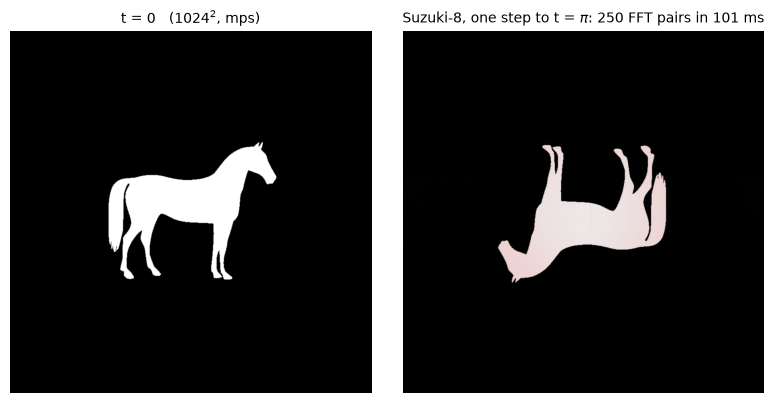

In [10]:
# The one-step Suzuki-8 flip from section 4, now on a 1024^2 grid on the GPU --
# the identical function call, just handed torch tensors.
N_gpu = 1024
L_gpu = math.sqrt(math.pi * N_gpu / 2)

psi_gpu = get_initial_state(
    N_gpu, L_gpu, state_image="horse", blur=0.0, backend="torch"
)
V_gpu, K_gpu = get_propagators(N_gpu, L_gpu, backend="torch")

start = time.perf_counter()
flipped = suzuki_trotter_step(psi_gpu, V_gpu, K_gpu, math.pi, order=8)
if DEVICE == "mps":
    torch.mps.synchronize()
elapsed_ms = (time.perf_counter() - start) * 1e3

show_states(
    [psi_gpu, flipped],
    [
        f"t = 0   (1024$^2$, {DEVICE})",
        f"Suzuki-8, one step to t = $\\pi$: 250 FFT pairs in {elapsed_ms:.0f} ms",
    ],
    size=4.0,
)

## 7. Phase retrieval: recovering the horse from a noisy, phaseless camera

Real detectors have two problems: they measure **brightness, not phase**, and they are
**noisy**. Put a camera at the Fourier plane ($t = \pi/2$) and what it records is the
brightness of the field, corrupted by noise — the phase, the colours in our pictures,
is gone entirely. And the phase is where the picture lives.

So here is the game: **the algorithm is never shown the horse.** It gets the noisy
camera image, the physics, and two mild facts about the unknown picture: it is **real
and non-negative** (it is a picture), and it sits inside a **central box** (it fits in
the frame). Guess an image $x$, run it a quarter period forward through the simulator,
and ask that its brightness at the Fourier plane match the measurement — plus a
**total-variation** penalty (the summed jumps between neighbouring pixels), which
suppresses noise-fitting speckle while keeping sharp edges:

$$\text{loss}(x) \;=\; \big\|\,|\psi(\pi/2)| - \text{measured}\,\big\|^2
\;+\; \lambda \cdot \text{Regularisation}(x),
\qquad x \ge 0 \text{ inside the box}.$$

Torch autodiff differentiates straight through the integrator's FFTs, and the Adam
optimiser does the search. Two things worth knowing. Knowing the potential is *not* a
shortcut: it gives us the forward map, but the measured brightness has infinitely many
phase completions, so there is nothing to run backwards — it is the priors that select
the physical answer. And the upside-down "twin" image fits the data exactly as well as
the right-way-up one, so the reconstruction is allowed to come out flipped.

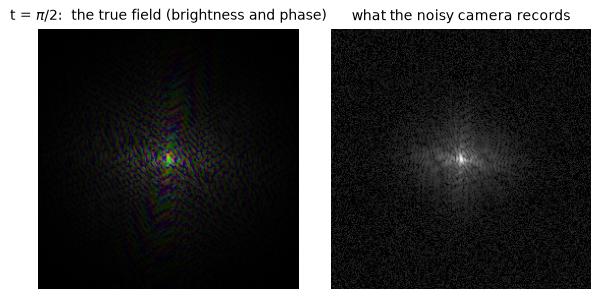

In [11]:
# The experiment. A quarter period after t = 0, whatever state was prepared
# arrives at the Fourier plane, where a noisy camera photographs its
# brightness. That photograph -- and nothing else -- is what we are given.
# A finer grid, just for this section: at 256^2 the TV prior's pixel-scale
# bias stops fattening the horse, and on the GPU it costs no extra wall time.
N_PR = 256
L_PR = math.sqrt(math.pi * N_PR / 2)

psi_true = get_initial_state(
    N_PR, L_PR, state_image="horse", blur=1.0, backend="torch", precision="single"
)
V_t, K_t = get_propagators(N_PR, L_PR, backend="torch", precision="single")
CDTYPE = psi_true.dtype  # complex64: every state handed to evolve shares this type

QUARTER = math.pi / 2  # a quarter period, evolved in 32 Lie-Trotter steps

with torch.no_grad():
    # the field at the camera (as_tensor is a no-op on tensors; it narrows
    # the static type to torch for the tensor-only calls below)
    psi_half = torch.as_tensor(evolve(psi_true, V_t, K_t, QUARTER, 32))
    torch.manual_seed(42)
    sigma = abs(psi_half).mean()  # noise as big as the signal
    measured = (abs(psi_half) + sigma * torch.randn_like(abs(psi_half))).clamp(min=0)

show_states(
    [psi_half, measured],
    [
        "t = $\\pi$/2:  the true field (brightness and phase)",
        "what the noisy camera records",
    ],
    gamma=[0.35, 0.35],  # brighten the faint Fourier-plane structure
)

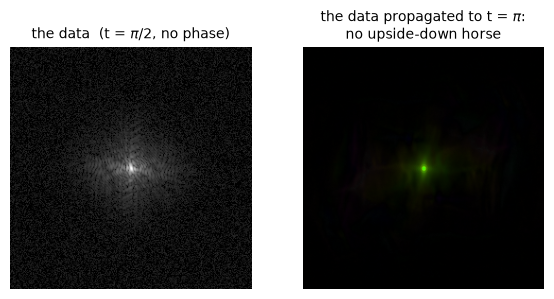

In [12]:
# Just how much did the camera lose? Propagate the data itself -- noisy and
# phaseless -- one more quarter period, to t = pi, where the true state would
# show the horse upside down. No phase, no picture: the physics has nothing
# to focus.
with torch.no_grad():
    phaseless_pi = evolve(measured.to(CDTYPE), V_t, K_t, QUARTER, 32)

show_states(
    [measured, phaseless_pi],
    [
        "the data  (t = $\\pi$/2, no phase)",
        "the data propagated to t = $\\pi$:\nno upside-down horse",
    ],
    gamma=[0.35, 1],
)

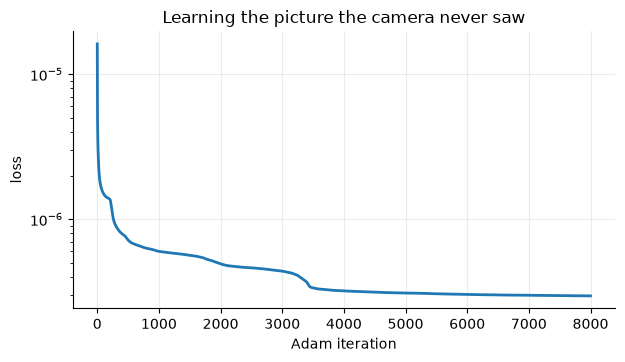

In [13]:
# Recover the unknown image by gradient descent THROUGH the physics.
# Non-negativity is built in (the image is a square); the support prior is a
# plain central box, not the horse's outline; the TV penalty keeps the
# optimiser from spending itself fitting the noise. ~25 s on Apple silicon.
margin = N_PR // 4 - 4
support = torch.zeros(N_PR, N_PR, device=measured.device)
support[margin : N_PR - margin, margin : N_PR - margin] = 1.0

TV_LAMBDA = 1e-3


def tv(image):
    """Total variation: the summed jumps between neighbouring pixels."""
    return (image[1:, :] - image[:-1, :]).abs().mean() + (
        image[:, 1:] - image[:, :-1]
    ).abs().mean()


def reconstruct(measured, V, K, support, lam=TV_LAMBDA, iters=8000):
    """Recover the image whose Fourier-plane brightness matches ``measured``."""
    n = measured.shape[-1]
    torch.manual_seed(0)
    a = (0.1 * torch.randn(n, n, device=measured.device)).requires_grad_(True)
    optimiser = torch.optim.Adam([a], lr=0.1)
    losses = []
    for _ in range(iters):
        optimiser.zero_grad()
        x = (a**2) * support  # real, non-negative, inside the box
        x = x / torch.linalg.vector_norm(x)
        psi_out = evolve(x.to(CDTYPE), V, K, QUARTER, 32)
        loss = ((abs(psi_out) - measured) ** 2).mean() + lam * tv(x)
        loss.backward()
        optimiser.step()
        losses.append(loss.item())
    with torch.no_grad():
        x = (a**2) * support
        return x / torch.linalg.vector_norm(x), losses


horse_recovered, losses = reconstruct(measured, V_t, K_t, support)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(losses, lw=2)
ax.set_xlabel("Adam iteration")
ax.set_ylabel("loss")
ax.set_title("Learning the picture the camera never saw")
tidy(ax)
plt.show()

overlap with the true image: 0.937


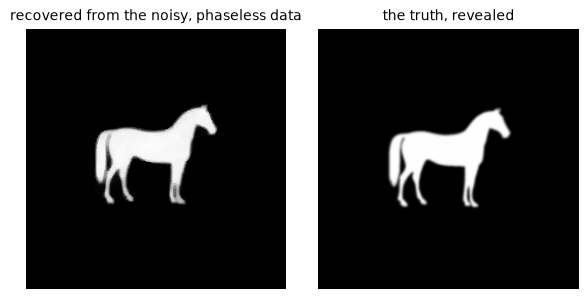

In [14]:
# The reveal: what the optimiser found in the noisy data -- and, for the
# first time in this section, the truth it was never shown.
with torch.no_grad():
    overlap = float((horse_recovered * abs(psi_true)).sum())
print(f"overlap with the true image: {overlap:.3f}")

show_states(
    [horse_recovered, psi_true],
    ["recovered from the noisy, phaseless data", "the truth, revealed"],
)

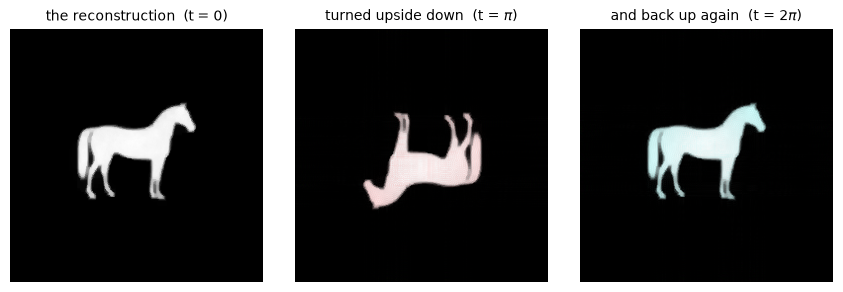

In [15]:
# And now that we hold a full state, we can do physics with it: half a period
# turns the recovered horse upside down; a full period brings it home.
with torch.no_grad():
    flipped = evolve(horse_recovered.to(CDTYPE), V_t, K_t, 2 * QUARTER, 64)
    revived = evolve(flipped, V_t, K_t, 2 * QUARTER, 64)

show_states(
    [horse_recovered, flipped, revived],
    [
        "the reconstruction  (t = 0)",
        "turned upside down  (t = $\\pi$)",
        "and back up again  (t = 2$\\pi$)",
    ],
    size=2.9,
)

## Recap

- **Forward Euler** grows the norm on every step, for every step size: it always blows
  up, and $\Delta t$ only chooses *when*.
- **Splitting methods** conserve the norm exactly at any step size; their error comes
  from $K$ and $V$ not commuting, is gloriously visible after one huge step, and dies
  at the method's theoretical order as steps shrink — halve the step for twice the
  accuracy with Lie–Trotter, or 256× with Suzuki–Trotter order 8.
- **High order buys giant steps**: one order-8 step crosses half a period and flips
  the image.
- **The physics runs backwards too**: because every step is differentiable torch
  operations, autodiff inverts the simulator — gradient descent recovers a horse it
  was never shown, from nothing but a noisy, phaseless Fourier-plane
  photograph, with a total-variation prior cleaning up the noise.
- All of it is FFTs and elementwise phases — and because the operators in
  [`quantum_oscillator/operators.py`](src/quantum_oscillator/operators.py) are written against the
  Array API via `array_api_compat.array_namespace`, the *same source* ran every
  experiment above on NumPy/CPU and on `torch`/Apple-GPU. Write the maths once; let
  the data decide where it runs.